# Marketing Application

We apply our constrained empirical Bayes (EB) denoising methods to a marketing data set, denoising the distribution of the effect of receiving a marketing e-mail on customer behavior across covariate strata. We model each stratum's effect as a latent log-odds-ratio observed through a Fisher noncentral hypergeometric likelihood.

The notebook is organized into three parts: setting up the data, computing the EB denoisers, and plotting the results. The final figure reproduces the marketing figure in the paper (see the figure-mapping table in the README).

In [1]:
from npeb.NCHGMixture import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

/Users/aqjaffe/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/aqjaffe/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Set up data

The data set is built from the Hillstrom e-mail marketing data set in `data/make_marketing_dataset.ipynb`, which aggregates customer visits within each covariate stratum, summarizes the effect of the e-mail by a per-stratum log-odds ratio, and saves the result to a `.pkl` file. We load that file below: `table` holds the 2x2 visit / non-visit counts per stratum for the treated and control arms, and `lor` holds the plug-in log-odds ratios.

In [ ]:
# Load the pre-built marketing data set (see data/make_marketing_dataset.ipynb).
marketing = np.load('data/marketing_data.pkl', allow_pickle=True)
table = marketing[['Z1', 'X1', 'Z2', 'X2']].values  # per-stratum 2x2 counts
lor = marketing['lor'].values                        # plug-in log-odds ratios
n = table.shape[0]

## Compute denoisers

We now compute the three EB denoisers of interest: the unconstrained denoiser, the (marginal) variance-constrained denoiser, and the (marginal) distribution-constrained denoiser. This requires adding a noncentral hypergeometric likelihood class to the `npeb` package.

### Unconstrained empirical Bayes

We fit the NPMLE for the noncentral hypergeometric likelihood and form the unconstrained EB posterior-mean denoiser $\hat{\delta}_{\mathcal{B}}$.

In [5]:
eb_model = NCHGMixture(component_std=0.1)
eb_model.initialize_atoms_grid(-3, 3, 0.01)
eb_model.fit(table, solver='mosek')
eb = eb_model.posterior_mean(table)

Computing kernel matrix: done.
Solving for discretized NPMLE: done.


### Variance-constrained empirical Bayes

We rescale $\hat{\delta}_{\mathcal{B}}$ to match the estimated prior mean and standard deviation, giving $\hat{\delta}_{\mathcal{MVCB}}$.

In [6]:
prior_mean = eb_model.prior_mean()
prior_std  = eb_model.prior_std()
emvcb = (eb - prior_mean) * prior_std / eb.std() + prior_mean

### Distribution-constrained empirical Bayes

We map each denoised value through the estimated prior quantile function (a one-dimensional optimal-transport step) to obtain $\hat{\delta}_{\mathcal{MDCB}}$.

In [7]:
n_sub = 200
u = (np.arange(n * n_sub) + 0.5) / (n * n_sub)
emdcb = eb_model.prior_quantile(u).reshape(n, n_sub).mean(1)

## Plot

Finally, we plot histograms of the raw log-odds-ratio summaries alongside the unconstrained, variance-constrained, and distribution-constrained EB denoised effects, with the estimated prior density $\hat{G}_n$ overlaid on the unconstrained panel.

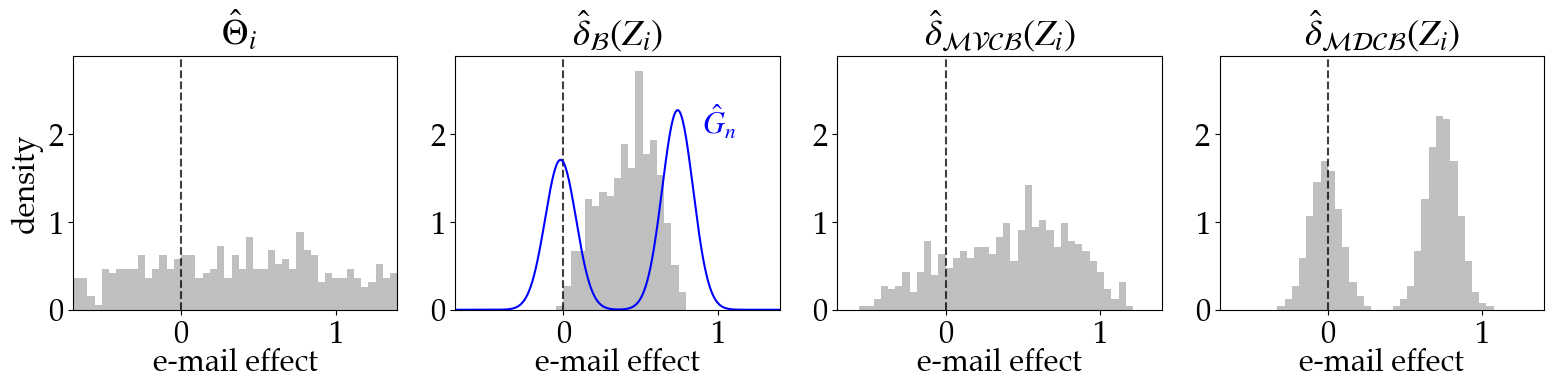

In [24]:
plt.rcParams.update({'font.size': 22,
                     'mathtext.fontset': 'stix',
                     'font.family': 'serif',
                     'font.serif':'Palatino'})

xl, yl = (-0.7, 1.4), (0., 2.9)
bins = np.linspace(xl[0], xl[1], 46)
mus  = np.linspace(xl[0], xl[1], 400)
    
def panel(ax, data, title, showylabel=False):
    ax.hist(data, bins=bins, density=True,
            color='black', alpha=0.25)
    ax.axvline(0., color='black', linestyle='dashed', alpha=0.75)
    # ax.plot(mus, eb_model.prior_pdf(mus), color='blue', linewidth=2.0,
    #         label='$\\widehat{G}_n$' if showlegend else None)
    ax.set_title(title)
    ax.set_xlim(xl)
    ax.set_ylim(yl)
    #ax.set_xlabel('log-odds ratio')
    ax.set_xlabel('e-mail effect')
    ax.xaxis.set_label_coords(0.5, -0.15)
    if showylabel:
        ax.set_ylabel('density')

fig, ax = plt.subplots(1, 4, figsize=(16,4.5),sharex=True)

panel(ax[0], lor, '$\\hat{\\,\\,\\Theta}_i$', showylabel=True)
panel(ax[1], eb, '$\\hat{\\delta}_{\\mathcal{B}}(Z_i)$')
ax[1].plot(mus, eb_model.prior_pdf(mus), color='blue', linewidth=1.5)
ax[1].text(0.9,2, "$\\hat{G}_n$", color='blue')
panel(ax[2], emvcb, '$\\hat{\\delta}_{\\mathcal{MVCB}}(Z_i)$')
panel(ax[3], emdcb, '$\\hat{\\delta}_{\\mathcal{MDCB}}(Z_i)$')

plt.tight_layout()
plt.savefig('figs/marketing.pdf')
plt.savefig('figs/marketing.png')
plt.show()